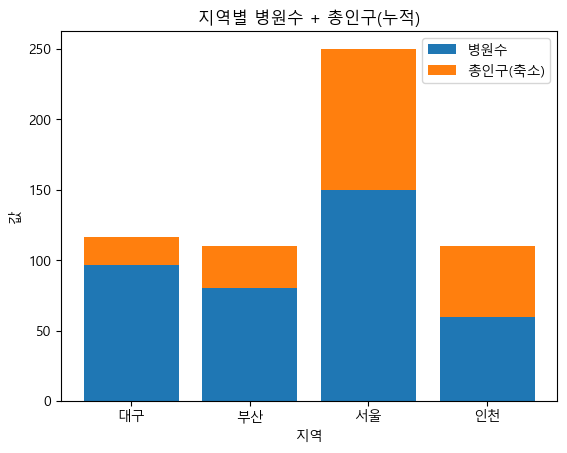

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역" : ["서울", "부산", "대구"],
    "총인구" : [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역" : ["서울", "부산", "인천"],
    "병원수" : [150, 80, 60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1, df2, on = "지역", how = "outer")
merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와 총인구의 평균으로 정의한다.
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())
merged

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫번째 막대
plt.bar(merged['지역'], merged['병원수'], label='병원수')

# 두번째 막대
# bottom => 기존의 막대 위에 쌓는다.
plt.bar(merged['지역'], merged['총인구'] / 10000, bottom=merged['병원수'], label='총인구(축소)')

plt.title('지역별 병원수 + 총인구(누적)')
plt.xlabel('지역')
plt.ylabel('값')

# 범례 표시
plt.legend()

plt.show()

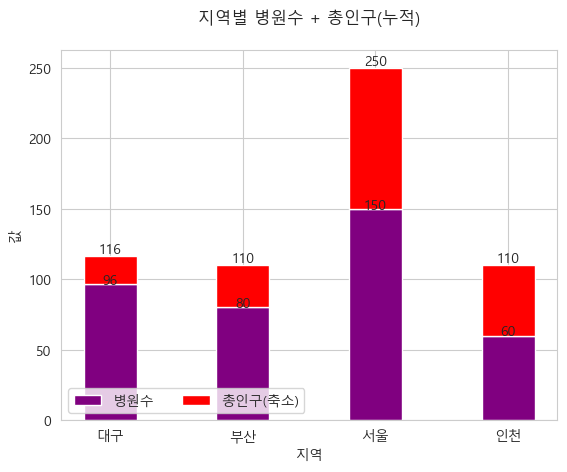

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역" : ["서울", "부산", "대구"],
    "총인구" : [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역" : ["서울", "부산", "인천"],
    "병원수" : [150, 80, 60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1, df2, on = "지역", how = "outer")
merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와 총인구의 평균으로 정의한다.
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())
merged

# seaborn 스타일 지정
sns.set_style('whitegrid') # 배경 스타일 설정, / dark: 그리드 없이 어두운 배경 지정, whitegrid : 그리드 있는 흰 배경
sns.set_palette('pastel') # 색상 스타일 지정 / deep : 진하게 , pastel

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫번째 막대
plt.bar(merged['지역'], merged['병원수'], label='병원수', color='purple', width=0.4)

for i in range(len(merged)):
    plt.text(
        i,
        merged['병원수'][i],
        int(merged['병원수'][i]),
        ha='center'
    )
    

# 두번째 막대
# bottom => 기존의 막대 위에 쌓는다.
plt.bar(merged['지역'], merged['총인구'] / 10000, bottom=merged['병원수'], label='총인구(축소)', color='red', width=0.4)

for i in range(len(merged)):
    tot = merged['병원수'][i] + merged['총인구'][i] / 10000
    plt.text(
        i,
        tot,
        int(tot),
        ha='center',
        va='bottom'
    )

plt.title('지역별 병원수 + 총인구(누적)', pad=20)
plt.xlabel('지역')
plt.ylabel('값')

# 범례 표시
plt.legend(
    loc='lower left',
    # bbox_to_anchor=(0,0),
    ncol=2
)

plt.show()